# Класифікація зображень і базова згорткова мережа
*pip install torchvision*

## Бізнес-контекст
Компанія VisionScan AI розробляє систему автоматичного розпізнавання рукописних цифр для обробки банківських документів.
Ваше завдання — створити першу версію моделі, яка класифікує цифри 0-9 за зображеннями, використовуючи PyTorch.
## Завдання 1
Підготуйте дані.
- Використовуйте датасет MNIST із torchvision.datasets.
- Завантажте навчальну і тестову вибірки.
- Перетворіть зображення в тензори та нормалізуйте їх.
- Створіть DataLoader із батчем розміром 64.

In [1]:
import torch
from torchvision import datasets, transforms
# перетворення - як завантажувати зображення до проєкту
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# Завантажте навчальну і тестову вибірки.
train_dataset = datasets.MNIST(root='data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='data', train=False, download=True, transform=transform)


100.0%
100.0%
100.0%
100.0%


In [7]:
# Створіть DataLoader із батчем розміром 64.
from torch.utils.data import DataLoader
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False)
print(len(train_loader), len(test_loader))

938 157


64


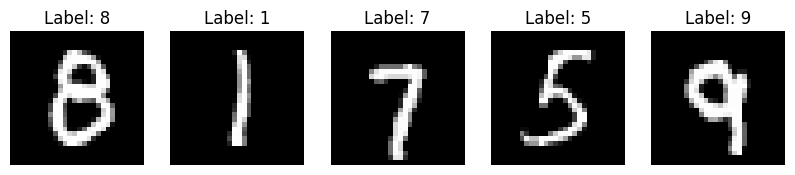

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

In [6]:
# Візуалізуємо кілька результатів
import matplotlib.pyplot as plt

train_iter = iter(train_loader)
images, labels = next(train_iter)
print(len(labels))

plt.figure(figsize=(10,2))
for i in range(5) :
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")
plt.show()

images[0]

## Завдання 2
Побудуйте просту згорткову нейронну мережу.
- Використовуйте шари:
    - Conv2d(1, 16, kernel_size=3);
    - ReLU();
    - MaxPool2d(2);
    - Flatten();
    - Linear(16 * 13 * 13, 10).
- Функція втрат — CrossEntropyLoss,
- оптимізатор — Adam(lr=0.001).
- Навчіть модель 10 епох.

In [11]:
import torch.nn as nn
import torch.optim as optim

class ConvNN(nn.Module):
    def __init__(self):
        super(ConvNN, self).__init__()
        self.conv = nn.Conv2d(
            in_channels=1,    # сірий - 1, кольоровий (RGB) - 3
            out_channels=16,  # кількість ознак
            kernel_size=3     # "вікно" згортки 3х3
        )
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)  # "вікно" 2x2
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 13 * 13, 10)

    def forward(self, x):    # 28x28
        x = self.conv(x)     # 26x26 x16
        x = self.relu(x)
        x = self.pool(x)     # 13x13
        x = self.flatten(x)
        x = self.fc(x)       # 13x13x16 (2704)
        return x

model = ConvNN()
loss_f = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
# Навчіть модель 10 епох.
epochs = 10
losses = []
for epoch in range(epochs) :
    total_loss = 0.0  # загальні втрати за епоху
    for images,labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = loss_f(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch: {epoch+1}, Loss: {total_loss}")

Epoch: 1, Loss: 22.740578223543707
Epoch: 2, Loss: 21.278964291443117
Epoch: 3, Loss: 18.360238952896907
Epoch: 4, Loss: 16.986506028828444
Epoch: 5, Loss: 15.849497336104832
Epoch: 6, Loss: 15.178070552698046
Epoch: 7, Loss: 12.833808461014996
Epoch: 8, Loss: 11.647820472724561
Epoch: 9, Loss: 10.15602496676729
Epoch: 10, Loss: 10.194478492281632


## Завдання 3
Відстежуйте та візуалізуйте процес навчання.
- Виведіть втрати за епохами.
- Побудуйте графік залежності loss від епох.
- Збережіть модель у файл mnist_cnn.pth.

In [22]:
losses

[22.740578223543707,
 21.278964291443117,
 18.360238952896907,
 16.986506028828444,
 15.849497336104832,
 15.178070552698046,
 12.833808461014996,
 11.647820472724561,
 10.15602496676729,
 10.194478492281632]

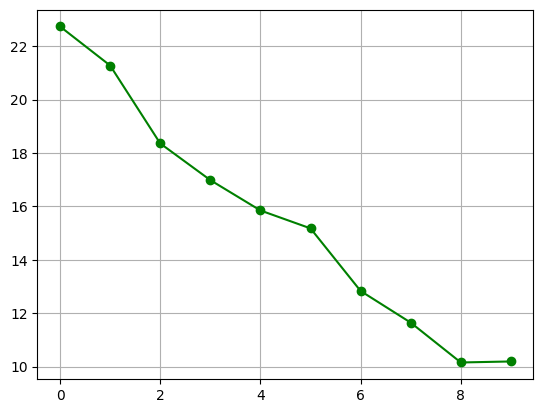

In [23]:
plt.plot(losses, 'g-o')
plt.grid()
plt.show()

## Завдання 4
Перевірте точність моделі на тестовій вибірці та оформіть результати:

In [24]:
correct = 0
total = 0
mis = []
with torch.no_grad():
    for images, labels in test_loader :
        output = model(images)
        _, predicted = torch.max(output, 1)
        total += len(labels)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)) :
            if predicted[i] != labels[i] :
                mis.append({
                    "label": labels[i],
                    "predicted": predicted[i],
                    "image": images[i]
                })
print(len(mis))
# точність: відсоток правильних передбачень
# втрати: відсоток помилок
# mis - приклади помилок (неправильних передбачень)

174


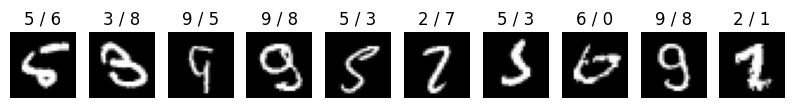

In [25]:
plt.figure(figsize=(10,2))
for i in range(10) :
    plt.subplot(1, 10, i+1)
    plt.imshow(mis[i]['image'].squeeze(), cmap="gray")
    plt.title(f"{mis[i]['label']} / {mis[i]['predicted']}")
    plt.axis("off")
plt.show()